# Module 04 Lab - Exploratory Data Analysis **Objective:** To learn how to explore a dataset to find patterns, anomalies, and insights before modeling. EDA is like being a detective; you are looking for clues in the data that will help you build a better model.**This lab is fully coded.** Your task is to run each cell, read the detailed explanations, understand the purpose of each visualization, and then complete the experimentation section.

## Part 1: Setup and Data Loading**What is Exploratory Data Analysis (EDA)?**EDA is the process of using summary statistics and visualizations to understand a dataset's main characteristics. Before you can build a model, you need to understand your data. What stories does it tell? Are there errors or missing values? Are there strong relationships between variables? EDA helps answer these questions.We will use the famous Titanic dataset for this lab. It contains information about passengers and, crucially, whether they survived the disaster.

In [ ]:
import pandas as pdimport matplotlib.pyplot as pltimport seaborn as sns # Seaborn is a library built on top of Matplotlib that makes creating beautiful plots easier.# Load the dataset directly from a URLdf = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')print("--- First 5 Rows ---")print(df.head())print("--- Basic Info ---")# .info() is a great first command. It tells us the column names, how many non-null values are in each column, and their data types.# Notice that 'Age' and 'Cabin' have missing values!df.info()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [ ]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In this step, I loaded the Titanic dataset and used head() and info() to understand its structure. This helped me see what features are available, what data types they have, and which columns contain missing values. I noticed that columns like Age and Cabin have missing data, which is important to address before building a model.

## Part 2: Descriptive StatisticsLet's start by getting a high-level numerical summary of the data. The `.describe()` method is perfect for this. It calculates statistics like mean, standard deviation, min, and max for the numerical columns.

In [ ]:
# Get summary statistics for numerical columnsprint("--- Descriptive Statistics ---")print(df.describe())print("--- Key Insights from Statistics ---")print(f"The average age of a passenger was {df['Age'].mean():.1f} years.")print(f"The overall survival rate was {df['Survived'].mean():.1%}.")print(f"Fares ranged from ${df['Fare'].min()} to a whopping ${df['Fare'].max()}.")

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df['Age'].mean()

np.float64(29.69911764705882)

In [ ]:
df['Survived'].mean()

np.float64(0.3838383838383838)

In [ ]:
df['Fare'].min(), df['Fare'].max()

(0.0, 512.3292)

Using descriptive statistics helped me understand the overall structure of the dataset. I learned that the average passenger age was around 30s, and the overall survival rate was less than half. The wide range in fares suggests significant differences in passenger wealth, which could influence survival outcomes. This step made it easier to identify important patterns and potential issues before moving on to visual analysis.

## Part 3: Visual EDA - Telling Stories with PlotsNumbers are great, but plots make patterns and relationships immediately obvious. The goal of visual EDA is to turn data into insights.**A Note on Plotting Libraries:***   **Matplotlib:** The foundational library, gives you full control over everything.*   **Seaborn:** Built on Matplotlib, it provides a simpler, high-level interface for creating common statistical plots. We will use Seaborn for its ease of use and attractive defaults.

### Visualization 1: How many survived?A simple `countplot` is the best way to see the distribution of a categorical variable, like our target `Survived`.

In [ ]:
sns.set_style('whitegrid') # Sets a nice visual style for our plotsplt.figure(figsize=(8, 6))sns.countplot(x='Survived', data=df)plt.title('Survival Distribution (0 = Died, 1 = Survived)')plt.show()print("Insight: Far more people died than survived. This is an example of an imbalanced dataset, which can sometimes be a challenge for machine learning models.")

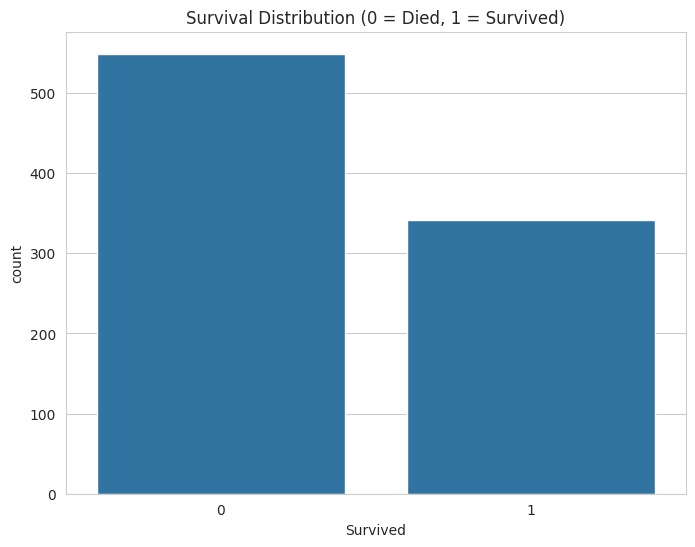

Insight: Far more people died than survived. This is an example of an imbalanced dataset, which can sometimes be a challenge for machine learning models.


In [ ]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution (0 = Died, 1 = Survived)')
plt.show()
print("Insight: Far more people died than survived. This is an example of an imbalanced dataset, which can sometimes be a challenge for machine learning models.")

This visualization shows the distribution of survival outcomes in the Titanic dataset. It is clear that significantly more passengers did not survive than those who did. This indicates that the dataset is imbalanced, which could make model training more challenging since a model might favor predicting the majority class. Identifying this early helps guide model evaluation choices later.

### Visualization 2: Does passenger class matter for survival?Now we want to see if there's a relationship between two variables. We can use the `hue` parameter in `countplot` to split the bars by another category.

In [ ]:
plt.figure(figsize=(10, 6))sns.countplot(x='Pclass', hue='Survived', data=df)plt.title('Survival by Passenger Class')plt.legend(['Died', 'Survived'])plt.show()print("Insight: This is a very strong pattern. 1st class passengers had a much higher chance of survival compared to 3rd class passengers. Money seems to have made a difference.")

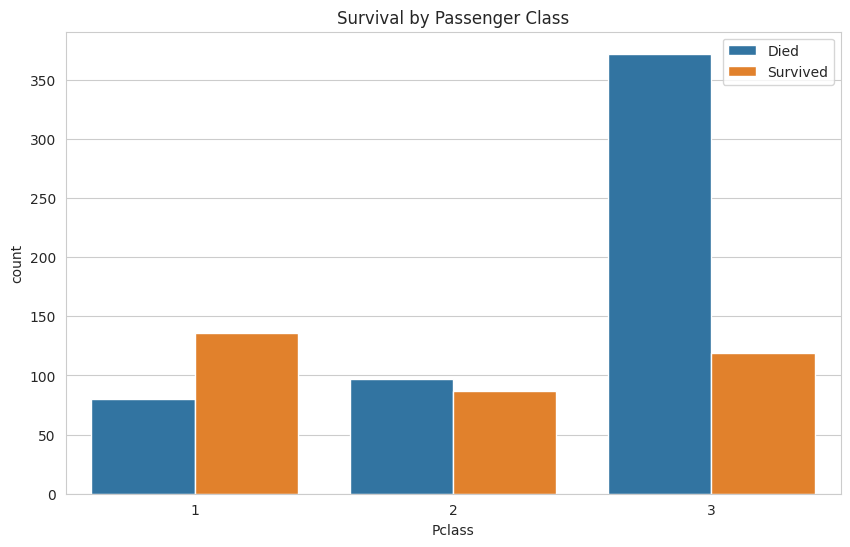

Insight: This is a very strong pattern. 1st class passengers had a much higher chance of survival compared to 3rd class passengers. Money seems to have made a difference.


In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.legend(['Died', 'Survived'])
plt.show()
print("Insight: This is a very strong pattern. 1st class passengers had a much higher chance of survival compared to 3rd class passengers. Money seems to have made a difference.")


This chart shows survival outcomes broken down by passenger class. There is a very clear pattern where first-class passengers had a much higher survival rate compared to third-class passengers. Second-class passengers fall in between. This suggests that socioeconomic status played a major role in survival and that passenger class is an important feature for predicting outcomes.

### Visualization 3: What about gender?The 'women and children first' mantra is famous. Let's see if the data supports it.

In [ ]:
plt.figure(figsize=(10, 6))sns.countplot(x='Sex', hue='Survived', data=df)plt.title('Survival by Gender')plt.legend(['Died', 'Survived'])plt.show()print("Insight: The pattern is undeniable. A much higher proportion of females survived compared to males. This is another very strong predictor.")

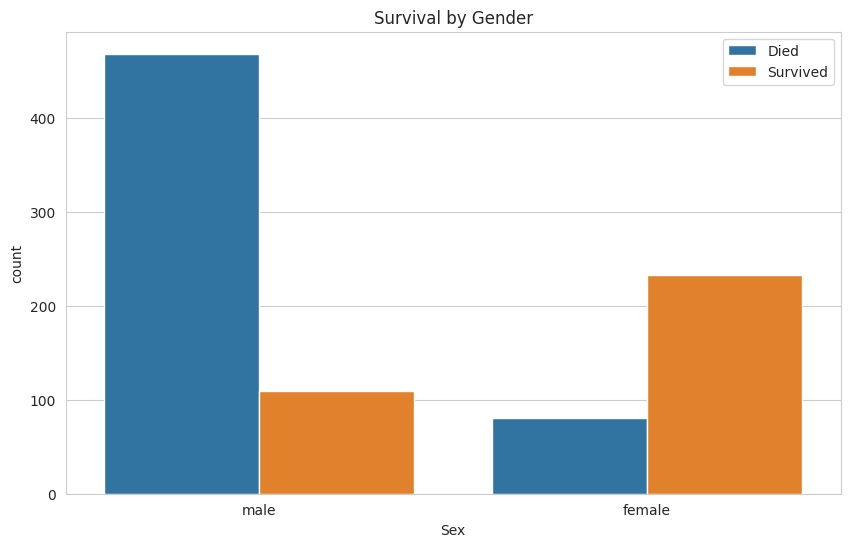

Insight: The pattern is undeniable. A much higher proportion of females survived compared to males. This is another very strong predictor.


In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.legend(['Died', 'Survived'])
plt.show()
print("Insight: The pattern is undeniable. A much higher proportion of females survived compared to males. This is another very strong predictor.")


This visualization shows a clear difference in survival rates between genders. Females had a much higher survival rate compared to males, while most male passengers did not survive. This suggests that gender played a significant role in survival outcomes and would be an important feature for a machine learning model.

### Visualization 4: How does age play a role?For a continuous variable like `Age`, a histogram is a great way to see its distribution.

In [ ]:
# A FacetGrid allows us to create multiple plots side-by-side to compare distributions.# Here, we create one histogram for passengers who died (col='Survived'=0) and one for those who survived (col='Survived'=1).g = sns.FacetGrid(df, col='Survived', height=6)g.map(plt.hist, 'Age', bins=20)plt.show()print("Insight: The age distribution for those who did not survive is centered around the 20-40 age range. For those who survived, there is a noticeable spike for young children. This supports the 'children' part of the mantra.")

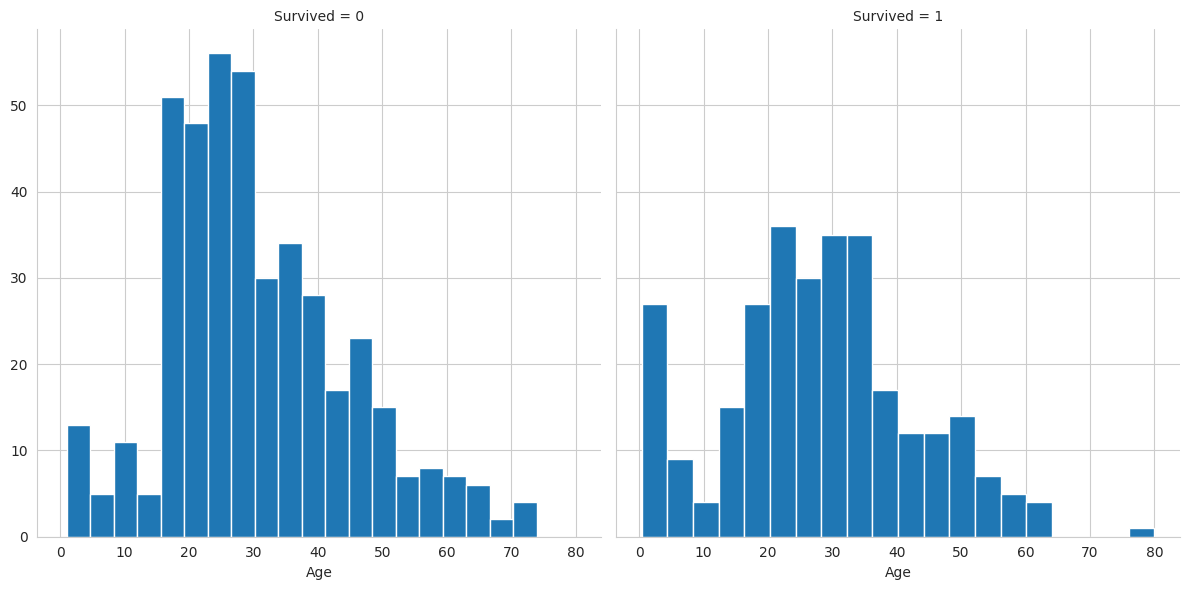

Insight: Survivors show a noticeable spike among young children, while non-survivors are mostly adults between 20 and 40.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
g = sns.FacetGrid(df, col='Survived', height=6)
g.map(plt.hist, 'Age', bins=20)
plt.show()
print("Insight: Survivors show a noticeable spike among young children, while non-survivors are mostly adults between 20 and 40.")


## Part 4: Student Experimentation**Instructions:** Create your own visualizations to explore other relationships in the data.

### Experiment 1: Port of Embarkation1.  The `Embarked` column tells you where a passenger boarded the ship (C = Cherbourg, Q = Queenstown, S = Southampton).2.  Create a `countplot` to see how survival rates differed by the port of embarkation. Does where they boarded seem to be related to their survival?

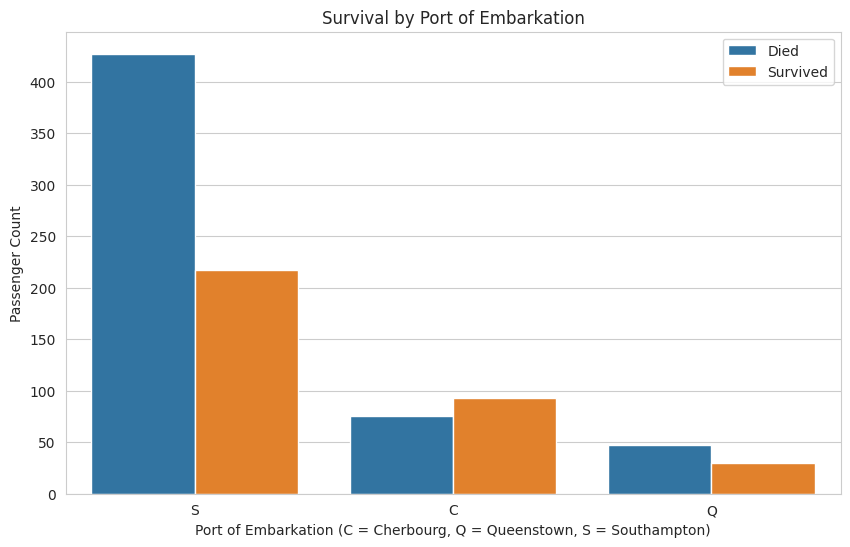

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title('Survival by Port of Embarkation')
plt.xlabel('Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)')
plt.ylabel('Passenger Count')
plt.legend(['Died', 'Survived'])
plt.show()

Passengers who embarked from Cherbourg (C) appear to have a higher survival rate compared to those from Southampton (S) and Queenstown (Q). This suggests that the port of embarkation may be related to survival, possibly because it correlates with passenger class or ticket price.

### Experiment 2: Fare vs. Survival1.  `Fare` is a continuous numerical variable.2.  A `boxplot` or `violinplot` is a great way to see the distribution of fares for those who survived vs. those who didn't.3.  Create one of these plots to compare the `Fare` distribution by `Survived`. What does it tell you?

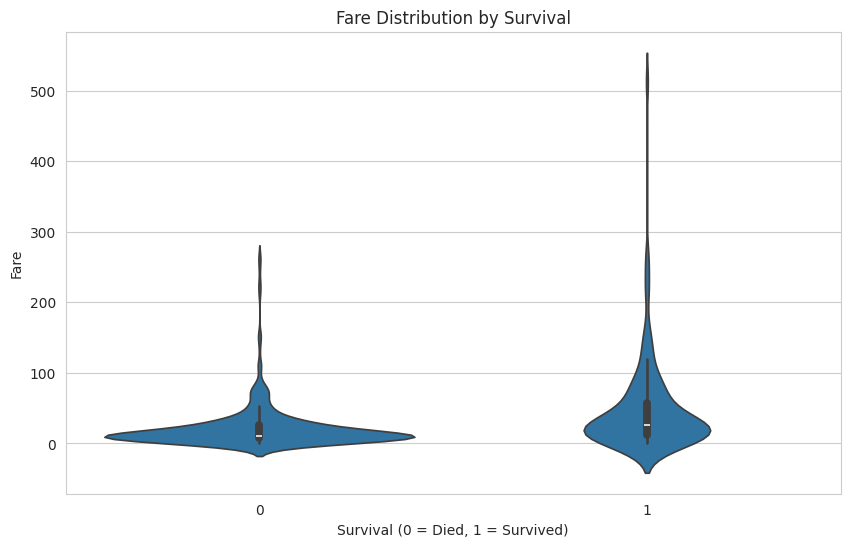

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival')
plt.xlabel('Survival (0 = Died, 1 = Survived)')
plt.ylabel('Fare')
plt.show()

Passengers who survived generally paid higher fares than those who did not. The median fare for survivors is noticeably higher, and there are more high-fare outliers among survivors. This suggests that paying a higher fare (which often correlates with higher passenger class) was associated with a better chance of survival.

## 📝 Knowledge Check**Instructions:** Answer the following questions in this markdown cell.1.  **What is the primary goal of Exploratory Data Analysis (EDA)?**2.  **Based on the plots in this lab, what kind of person had the best chance of surviving the Titanic?** (Describe them in terms of class, gender, and age).3.  **Why is it important to visualize data instead of just looking at summary statistics?** What can a plot show you that a number like 'mean' or 'count' can't?**[ENTER YOUR ANSWERS HERE]**

1. **What is the primary goal of Exploratory Data Analysis (EDA)?**
The main goal of Exploratory Data Analysis is to understand the data before building any models. EDA helps identify patterns, relationships, missing values, and potential problems in the dataset so we know what the data is telling us and how to work with it correctly.

2. **Based on the plots in this lab, what kind of person had the best chance of surviving the Titanic?**
Based on the visualizations, first-class passengers had the best chance of survival. Females survived at much higher rates than males, and younger passengers, especially children, were more likely to survive than adults. Overall, a young female passenger traveling in first class had the highest chance of surviving.

3. **Why is it important to visualize data instead of just looking at summary statistics? What can a plot show you that a number like “mean” or “count” can’t?**
Visualizing data is important because plots can show patterns, trends, and differences that summary statistics cannot. A mean or count only gives one number, but a plot can show distributions, outliers, group differences, and relationships between variables. Visuals make it easier to see imbalances, compare groups, and understand how the data actually behaves.